<a href="https://colab.research.google.com/github/sabithakrishnan/multimodal-image-analysis/blob/main/multimodalimage_recognition_clip%26simpleprompt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open-clip-torch datasets pillow torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


In [ ]:
import os
from pathlib import Path
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

class ProductionDatasetBuilder:
    def __init__(self, dataset_repo: str = "blanchon/EuroSAT_RGB"):
        self.repo = dataset_repo

    def build_local_directory(self, output_dir: str = "satellite_dataset"):
        dest_path = Path(output_dir)

        # Guard clause: avoid re-running if data exists
        if dest_path.exists() and any(dest_path.iterdir()):
            print(f"📦 Workspace directory '{output_dir}' already exists. Transitioning steps...")
            return

        print(f"📡 Accessing Hugging Face native parquet tables for '{self.repo}'...")
        # Loads clean tabular shards; completely bypasses legacy python execution scripts
        dataset_split = load_dataset(self.repo, split="train")

        # Dynamically infer the land-use taxonomy from the Metadata Table schema
        label_names = dataset_split.features["label"].names
        print(f"🎯 Verified {len(label_names)} target categories for extraction.")

        print("\n💾 Unpacking and storing satellite tensors to local filesystems...")
        for idx, sample in enumerate(tqdm(dataset_split, desc="Processing Satellite Tiles")):
            pil_img = sample["image"]
            label_id = sample["label"]

            # Sanitize naming structures to eliminate runtime mapping mistakes
            class_name = label_names[label_id].replace(" ", "")

            # Map path structure: satellite_dataset/IndustrialBuildings/tile_x.jpg
            class_folder = dest_path / class_name
            class_folder.mkdir(parents=True, exist_ok=True)

            file_name = class_folder / f"tile_{idx}.jpg"

            if pil_img.mode != "RGB":
                pil_img = pil_img.convert("RGB")

            pil_img.save(file_name, "JPEG")

        print(f"\n✅ Step 2 Complete! File mapping successfully resolved inside: '{dest_path.resolve()}'")

if __name__ == "__main__":
    builder = ProductionDatasetBuilder()
    builder.build_local_directory()


📡 Accessing Hugging Face native parquet tables for 'blanchon/EuroSAT_RGB'...


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  105MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 34.8MB            

...

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

🎯 Verified 10 target categories for extraction.

💾 Unpacking and storing satellite tensors to local filesystems...


Processing Satellite Tiles: 100%|██████████| 16200/16200 [00:31<00:00, 516.43it/s]


✅ Step 2 Complete! File mapping successfully resolved inside: '/content/satellite_dataset'


Evaluating Batches: 100%|██████████| 254/254 [00:55<00:00,  4.61it/s]
/tmp/ipykernel_943/780145193.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=f1_scores, palette="viridis")


0.8581975308641974
0.23680455134055628
0.295169069210499
0.23412793132364298


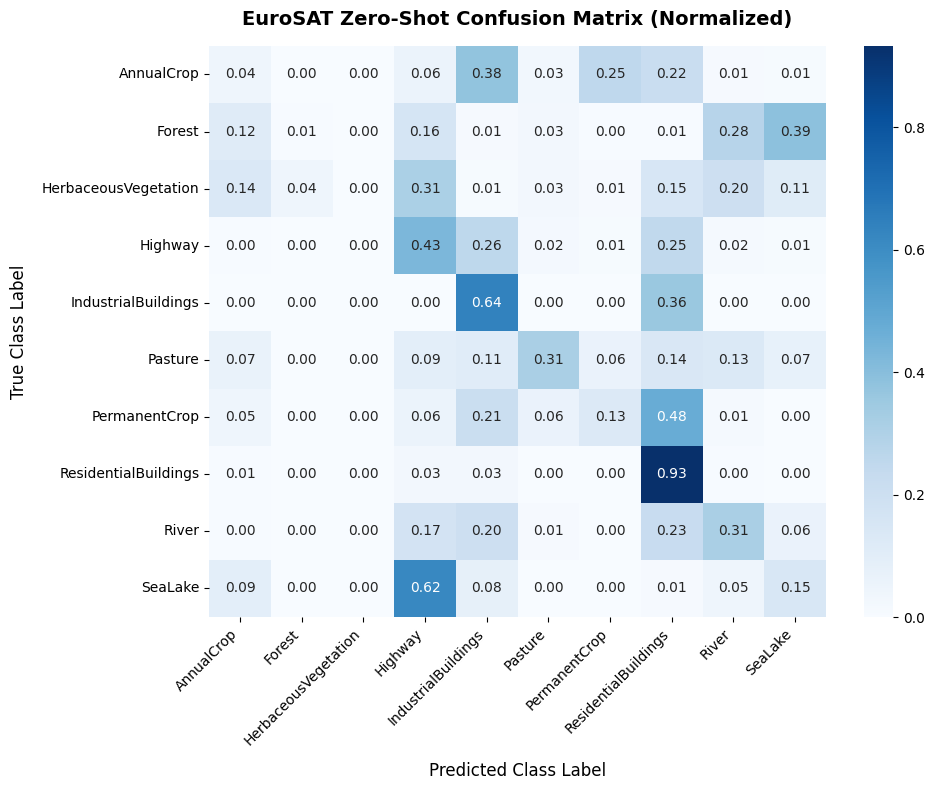

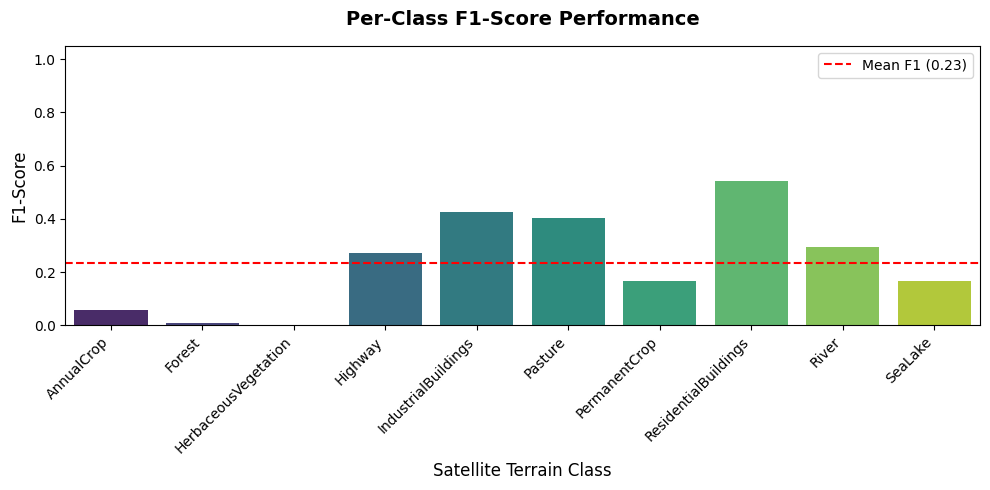

💾 F1-Score chart saved as 'per_class_f1_scores.png'


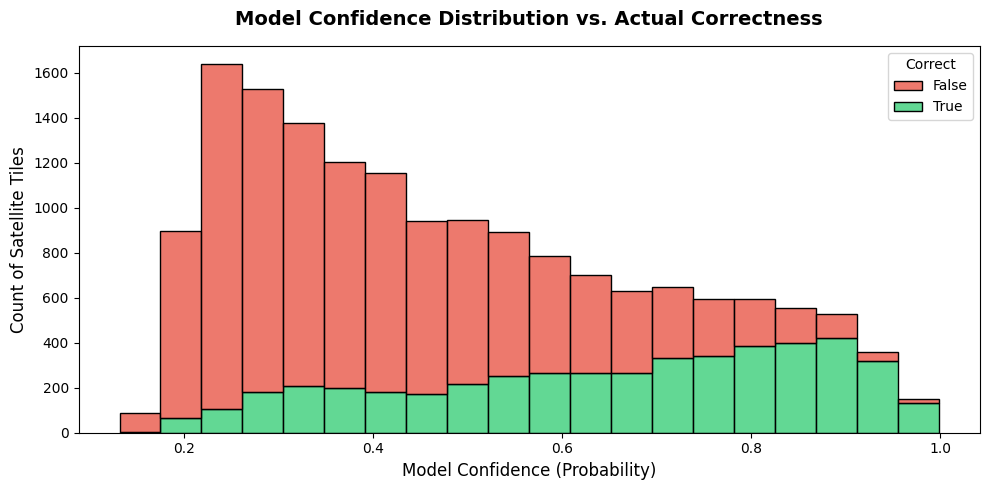

In [ ]:
import torch
import open_clip
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.datasets import ImageFolder

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    data_directory = "satellite_dataset"
    #Defining model
    model, _, preprocess = open_clip.create_model_and_transforms(
        'ViT-B-32',
        pretrained='laion2b_s34b_b79k',
        device=device
    )
    tokenizer = open_clip.get_tokenizer('ViT-B-32')
    #Evaluating the model rather than training
    model.eval()

    # Load dataset
    dataset = ImageFolder(root=data_directory, transform=preprocess)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)
    #Giving simple prompts
    prompts = [f"a centered satellite photograph of {cls.lower()} terrain" for cls in dataset.classes]
    text_tokens = tokenizer(prompts).to(device)

    correct_predictions = []
    total_predictions = []
    all_confidences = []
    all_correctness = []
    amp_dtype = torch.float16
    with torch.no_grad():
        #Encode
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        # Loop through batches of images
        for images, targets in tqdm(dataloader, desc="Evaluating Batches"):
            images = images.to(device)
            targets = targets.to(device)

            # Extracting visual features
            image_features = model.encode_image(images)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            predictions = similarity.argmax(dim=-1)
            max_probs, preds = similarity.max(dim=-1)
            # Track validation metrics
            correct_predictions.extend(predictions.cpu().numpy())
            total_predictions.extend(targets.cpu().numpy())
            all_confidences.extend(max_probs.cpu().numpy())
            all_correctness.extend((preds == targets.to(device)).cpu().numpy())
    # Compute and normalize the matrix
    cm = confusion_matrix(total_predictions, correct_predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    #compute classification report and extract per class F1 score
    report_dict = classification_report(total_predictions, correct_predictions, target_names=dataset.classes, output_dict=True)
    classes = dataset.classes
    f1_scores = [report_dict[cls]['f1-score'] for cls in classes]
   #compute performance metrics
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    total_samples = np.sum(cm)
    TN = total_samples - (TP + FP + FN)
# Adding a small epsilon (1e-7) prevents "division by zero" errors
    accuracy  = (TP + TN) /(TP+TN+FP+FN)
    precision = TP / (TP + FP + 1e-7)
    recall    = TP / (TP + FN + 1e-7) # Equivalent to Sensitivity
    f1        = 2 * (precision * recall) / (precision + recall + 1e-7)
    print(np.mean(accuracy))
    print(np.mean(precision))
    print(np.mean(recall))
    print(np.mean(f1))

    # Create the heatmap plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=dataset.classes,
        yticklabels=dataset.classes,
        cbar=True
    )

    plt.title("EuroSAT Zero-Shot Confusion Matrix (Normalized)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Predicted Class Label", fontsize=12, labelpad=10)
    plt.ylabel("True Class Label", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    # Plot F1-Scores
    plt.figure(figsize=(10, 5))
    sns.barplot(x=classes, y=f1_scores, palette="viridis")
    plt.axhline(y=np.mean(f1_scores), color='r', linestyle='--', label=f'Mean F1 ({np.mean(f1_scores):.2f})')
    plt.title("Per-Class F1-Score Performance", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Satellite Terrain Class", fontsize=12)
    plt.ylabel("F1-Score", fontsize=12)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("💾 F1-Score chart saved as 'per_class_f1_scores.png'")
    # Plot Confidence Distribution broken down by True vs False predictions
    plt.figure(figsize=(10, 5))
    df_perf = {"Confidence": all_confidences, "Correct": all_correctness}
    sns.histplot(data=df_perf, x="Confidence", hue="Correct", multiple="stack", bins=20, palette={True: "#2ecc71", False: "#e74c3c"})
    plt.title("Model Confidence Distribution vs. Actual Correctness", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Model Confidence (Probability)", fontsize=12)
    plt.ylabel("Count of Satellite Tiles", fontsize=12)
    plt.tight_layout()
    plt.show()